# Student Performance Prediction - NTI Final Project.




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

print("XGBoost installed:", HAS_XGBOOST)


XGBoost installed: True


In [4]:
df = pd.read_csv("/content/student_performance_dataset.csv")
df.head()


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [5]:
print("Rows and columns:", df.shape)


Rows and columns: (1000, 12)


In [6]:
df.dtypes


,0
student_id,int64
gender,object
study_time_hours,float64
attendance_percent,float64
sleep_hours,float64
parental_education,object
internet_access,object
extracurricular_activities,object
part_time_job,object
previous_grade,float64


In [7]:
df.isnull().sum()


,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.describe()


,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [10]:
df["final_grade"].value_counts()


,count
final_grade,
B,354
A,284
C,261
D,89
F,12


In [11]:
df.groupby("final_grade")["final_exam_score"].describe()[["min", "max"]]


,min,max
final_grade,,
A,90.0,100.0
B,80.0,89.9
C,70.0,79.9
D,60.0,69.9
F,46.8,59.7


In [12]:
df = df.drop(columns=["student_id", "final_exam_score"])
df.head()


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,A
3,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,D


## EDA


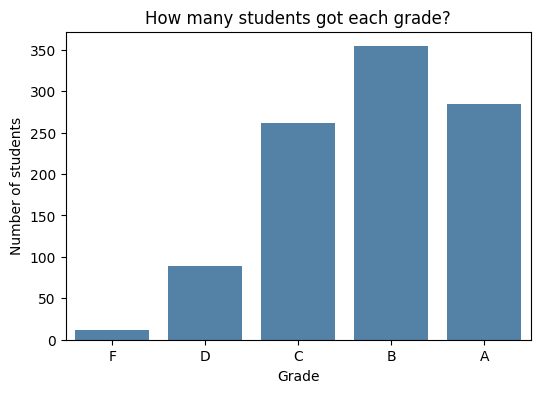

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="final_grade", order=["F","D","C","B","A"], color="steelblue")
plt.title("How many students got each grade?")
plt.xlabel("Grade")
plt.ylabel("Number of students")
plt.show()


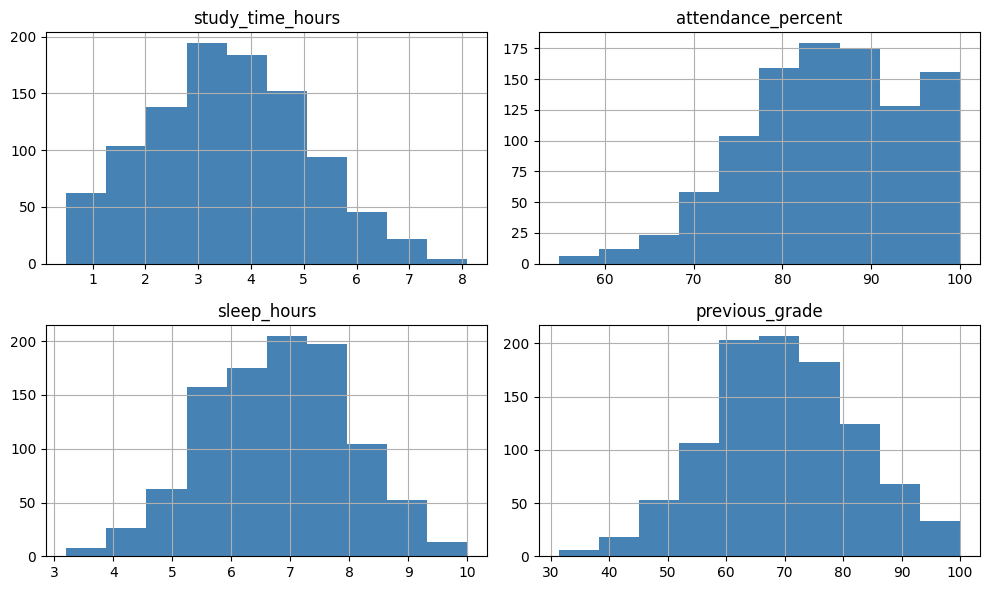

In [14]:
df.hist(figsize=(10, 6), color="steelblue")
plt.tight_layout()
plt.show()


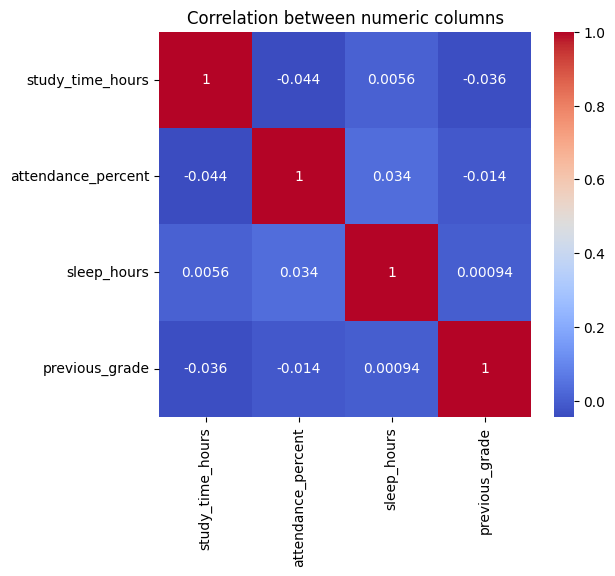

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation between numeric columns")
plt.show()


In [16]:
df["parental_education"] = df["parental_education"].fillna("None")
df["parental_education"].value_counts()


,count
parental_education,
High School,356
Bachelors,308
Masters,184
None,102
PhD,50


In [17]:
X = df.drop(columns=["final_grade"])
y = df["final_grade"]


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Grade letters:", label_encoder.classes_)
print("Turned into numbers:", label_encoder.transform(label_encoder.classes_))


Grade letters: ['A' 'B' 'C' 'D' 'F']
Turned into numbers: [0 1 2 3 4]


In [18]:
numeric_columns = ["study_time_hours", "attendance_percent", "sleep_hours", "previous_grade"]
categorical_columns = ["gender", "parental_education", "internet_access", "extracurricular_activities", "part_time_job"]

preprocessor = ColumnTransformer([
    ("numbers", StandardScaler(), numeric_columns),
    ("categories", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 800
Testing rows: 200


## Train our 6 Models

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(eval_metric="mlogloss", random_state=42)

print("Models we'll train:", list(models.keys()))


Models we'll train: ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'XGBoost']


In [22]:
trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    print(f"{name} done with training!!!!")


Logistic Regression done with training!!!!
KNN done with training!!!!
SVM done with training!!!!
Decision Tree done with training!!!!
Random Forest done with training!!!!
XGBoost done with training!!!!


## Evaluation Time



In [23]:
results = []

for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.655,0.662309,0.655,0.649378
1,KNN,0.535,0.544942,0.535,0.515076
2,SVM,0.630,0.658592,0.630,0.614661
3,Decision Tree,0.480,0.486287,0.480,0.482716
4,Random Forest,0.590,0.597395,0.590,0.578037
5,XGBoost,0.580,0.568818,0.580,0.571809


In [25]:
example_model = "Random Forest"
y_pred_example = trained_models[example_model].predict(X_test)
print(f"Classification report for {example_model}:\n")
print(classification_report(y_test, y_pred_example, target_names=label_encoder.classes_, zero_division=0))


Classification report for Random Forest:

              precision    recall  f1-score   support

           A       0.70      0.77      0.73        57
           B       0.55      0.58      0.56        71
           C       0.51      0.56      0.53        52
           D       0.80      0.22      0.35        18
           F       0.00      0.00      0.00         2

    accuracy                           0.59       200
   macro avg       0.51      0.43      0.43       200
weighted avg       0.60      0.59      0.58       200



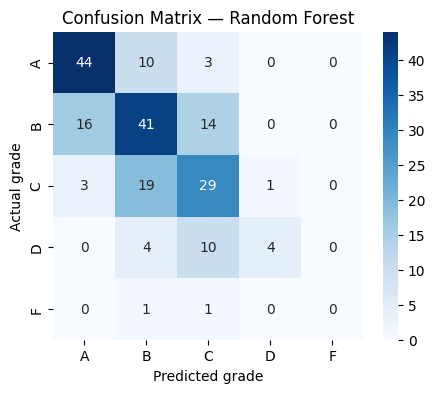

In [26]:
cm = confusion_matrix(y_test, y_pred_example)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix — {example_model}")
plt.xlabel("Predicted grade")
plt.ylabel("Actual grade")
plt.show()


## Comparison

In [27]:
comparison = results_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.655,0.662309,0.655,0.649378
1,SVM,0.630,0.658592,0.630,0.614661
2,Random Forest,0.590,0.597395,0.590,0.578037
3,XGBoost,0.580,0.568818,0.580,0.571809
4,KNN,0.535,0.544942,0.535,0.515076
5,Decision Tree,0.480,0.486287,0.480,0.482716


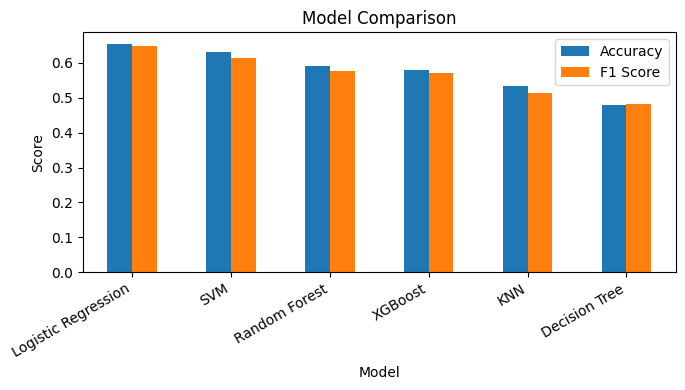

In [28]:
comparison.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar", figsize=(7,4))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## The Best Model

In [31]:
best_model_name = comparison.iloc[0]["Model"]
best_pipeline = trained_models[best_model_name]
print("Best model:", best_model_name)
comparison.iloc[[0]]


Best model: Logistic Regression


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.655,0.662309,0.655,0.649378


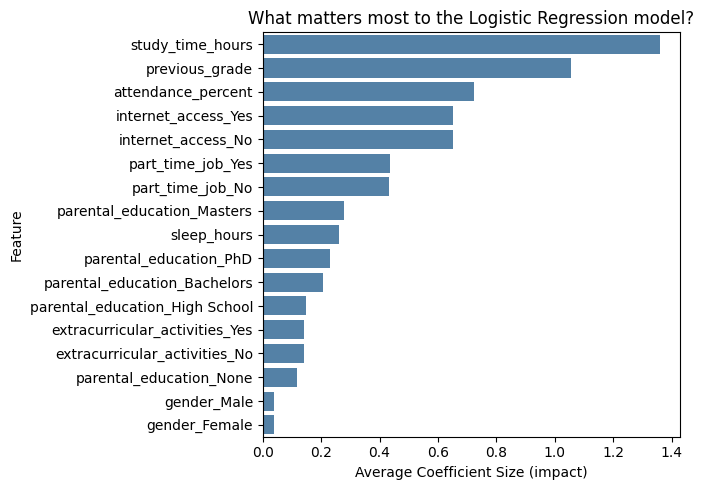

In [32]:

category_names = best_pipeline.named_steps["preprocessor"].named_transformers_["categories"].get_feature_names_out(categorical_columns)
all_feature_names = numeric_columns + list(category_names)

model_step = best_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):

    importances = model_step.feature_importances_
    importance_label = "Feature Importance"
elif hasattr(model_step, "coef_"):

    importances = np.abs(model_step.coef_).mean(axis=0)
    importance_label = "Average Coefficient Size (impact)"
else:
    importances = None

if importances is not None:
    importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        importance_label: importances,
    }).sort_values(importance_label, ascending=False)

    plt.figure(figsize=(7,5))
    sns.barplot(data=importance_df, x=importance_label, y="Feature", color="steelblue")
    plt.title(f"What matters most to the {best_model_name} model?")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} doesn't provide a simple built-in importance score.")


In [33]:
info_for_app = {
    "feature_names": list(X.columns),
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "category_options": {col: sorted(df[col].unique().tolist()) for col in categorical_columns},
    "numeric_ranges": {col: (float(df[col].min()), float(df[col].max()), float(df[col].mean())) for col in numeric_columns},
    "grade_names": list(label_encoder.classes_),
    "best_model_name": best_model_name,
}

saved_bundle = {
    "pipeline": best_pipeline,
    "label_encoder": label_encoder,
    "info": info_for_app,
}

joblib.dump(saved_bundle, "best_model.pkl")
print("Saved best_model.pkl! Best model was:", best_model_name)


Saved best_model.pkl! Best model was: Logistic Regression


In [34]:
reloaded = joblib.load("best_model.pkl")

one_student = X_test.iloc[[0]]
predicted_number = reloaded["pipeline"].predict(one_student)[0]
predicted_grade = reloaded["label_encoder"].inverse_transform([predicted_number])[0]

print("Student's info:")
print(one_student.to_dict(orient="records")[0])
print("\nPredicted grade:", predicted_grade)


Student's info:
{'gender': 'Male', 'study_time_hours': 6.3, 'attendance_percent': 75.5, 'sleep_hours': 6.6, 'parental_education': 'None', 'internet_access': 'Yes', 'extracurricular_activities': 'No', 'part_time_job': 'No', 'previous_grade': 67.8}

Predicted grade: A


## Thank you.
